In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import joblib

## 1) File paths and class map

In [2]:
DATA_DIR = Path("../data/raw")
CSV_DIR = Path("../data/processed")
LOGS_DIR = Path("../outputs/logs")
PLOTS_DIR = Path("../outputs/plots")

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "rest/rest_20260419_212016.csv": "rest",
    "rest/rest_20260419_212846.csv": "rest",
    "rest/rest_20260417_152340.csv": "rest",
    "rest/rest_20260417_152938.csv": "rest",
    "moderate/moderate_walking_20260407_120447.csv": "moderate",
    "moderate/moderate_walking_20260417_150822.csv": "moderate",
    "moderate/moderate_walking_20260417_151525.csv": "moderate",
    "moderate/moderate_stairs_20260411_224148.csv": "moderate",
    "moderate/moderate_stairs_20260417_163918.csv": "moderate",
    "moderate/moderate_stairs_20260417_164326.csv": "moderate",
    "intense/intense_running_20260414_195242.csv": "intense",
    "intense/intense_running_20260417_162157.csv": "intense",
    "intense/intense_running_20260417_160438.csv": "intense",
    "intense/intense_squats_20260411_223205.csv": "intense",
    "intense/intense_squats_20260417_153856.csv": "intense",
    "intense/intense_squats_20260417_154922.csv": "intense",
}

LABEL_MAP = {
    "rest": 0,
    "moderate": 1,
    "intense": 2
}


## 2) Load and clean each file

In [3]:
def load_and_clean_csv(file_path, class_label):
    df = pd.read_csv(file_path)

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.sort_values("timestamp").reset_index(drop=True)

    df["activity"] = class_label

    numeric_cols = ["temp", "emg_raw", "emg_env", "emg_state", "ax", "ay", "az", "hr"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df.loc[df["hr"] <= 0, "hr"] = np.nan

    df["hr"] = df["hr"].interpolate(limit_direction="both")
    df["hr"] = df["hr"].ffill().bfill()

    for col in numeric_cols:
        df[col] = df[col].interpolate(limit_direction="both")
        df[col] = df[col].ffill().bfill()

    df["acc_mag"] = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)

    df["dt"] = df["timestamp"].diff().dt.total_seconds()
    median_dt = df["dt"].median()
    df["dt"] = df["dt"].fillna(median_dt if pd.notna(median_dt) else 1.0)

    return df

## 3) Load all files

In [4]:
all_dfs = []

for fname, cls in FILES.items():
    path = DATA_DIR / fname
    print(path)
    df = load_and_clean_csv(path, cls)
    df["source_file"] = fname
    all_dfs.append(df)

full_df = pd.concat(all_dfs, ignore_index=True)

print(full_df.shape)
print(full_df[["source_file", "activity"]].drop_duplicates())
full_df.head()

..\data\raw\rest\rest_20260419_212016.csv
..\data\raw\rest\rest_20260419_212846.csv
..\data\raw\rest\rest_20260417_152340.csv
..\data\raw\rest\rest_20260417_152938.csv
..\data\raw\moderate\moderate_walking_20260407_120447.csv
..\data\raw\moderate\moderate_walking_20260417_150822.csv
..\data\raw\moderate\moderate_walking_20260417_151525.csv
..\data\raw\moderate\moderate_stairs_20260411_224148.csv
..\data\raw\moderate\moderate_stairs_20260417_163918.csv
..\data\raw\moderate\moderate_stairs_20260417_164326.csv
..\data\raw\intense\intense_running_20260414_195242.csv
..\data\raw\intense\intense_running_20260417_162157.csv
..\data\raw\intense\intense_running_20260417_160438.csv
..\data\raw\intense\intense_squats_20260411_223205.csv
..\data\raw\intense\intense_squats_20260417_153856.csv
..\data\raw\intense\intense_squats_20260417_154922.csv
(3873, 14)
                                        source_file  activity
0                     rest/rest_20260419_212016.csv      rest
283                

,timestamp,label,temp,emg_raw,emg_env,emg_state,ax,ay,az,hr,activity,acc_mag,dt,source_file
0,2026-04-19 21:20:31.861311,rest,33.56,60.0,3.0,0.0,16992.0,-996.0,900.0,91.0,rest,17044.942945,1.036625,rest/rest_20260419_212016.csv
1,2026-04-19 21:20:32.895670,rest,33.56,56.0,3.0,0.0,16856.0,-700.0,988.0,88.0,rest,16899.434310,1.034359,rest/rest_20260419_212016.csv
2,2026-04-19 21:20:33.929793,rest,33.56,59.0,3.0,0.0,16836.0,-620.0,908.0,85.0,rest,16871.862968,1.034123,rest/rest_20260419_212016.csv
3,2026-04-19 21:20:34.962679,rest,33.56,57.0,1.0,0.0,16848.0,-788.0,856.0,81.0,rest,16888.125532,1.032886,rest/rest_20260419_212016.csv
4,2026-04-19 21:20:35.998109,rest,33.56,61.0,1.0,0.0,16728.0,-672.0,1036.0,77.0,rest,16773.516745,1.035430,rest/rest_20260419_212016.csv


## 4) Window feature extraction

In [5]:
WINDOW_SEC = 10
STEP_SEC = 10

def waveform_length(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0.0
    return np.sum(np.abs(np.diff(x)))

def zero_crossings(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0
    x_centered = x - np.mean(x)
    return np.sum(np.diff(np.sign(x_centered)) != 0)

def slope_feature(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0.0
    return (x[-1] - x[0]) / len(x)

def extract_features_from_window(win):
    feats = {}

    # HR
    feats["hr_mean"] = win["hr"].mean()
    feats["hr_std"] = win["hr"].std()
    feats["hr_min"] = win["hr"].min()
    feats["hr_max"] = win["hr"].max()
    feats["hr_range"] = feats["hr_max"] - feats["hr_min"]

    # Temperature
    feats["temp_mean"] = win["temp"].mean()
    feats["temp_std"] = win["temp"].std()
    feats["temp_min"] = win["temp"].min()
    feats["temp_max"] = win["temp"].max()
    feats["temp_slope"] = slope_feature(win["temp"].values)

    # EMG
    feats["emg_raw_mean"] = win["emg_raw"].mean()
    feats["emg_raw_std"] = win["emg_raw"].std()
    feats["emg_env_mean"] = win["emg_env"].mean()
    feats["emg_env_std"] = win["emg_env"].std()
    feats["emg_rms"] = np.sqrt(np.mean(win["emg_raw"].values**2))
    feats["emg_mav"] = np.mean(np.abs(win["emg_raw"].values))
    feats["emg_wl"] = waveform_length(win["emg_raw"].values)
    feats["emg_zero_cross"] = zero_crossings(win["emg_raw"].values)
    feats["emg_state_mean"] = win["emg_state"].mean()

    # IMU axis stats
    for axis in ["ax", "ay", "az"]:
        feats[f"{axis}_mean"] = win[axis].mean()
        feats[f"{axis}_std"] = win[axis].std()
        feats[f"{axis}_min"] = win[axis].min()
        feats[f"{axis}_max"] = win[axis].max()

    # Magnitude stats
    feats["acc_mag_mean"] = win["acc_mag"].mean()
    feats["acc_mag_std"] = win["acc_mag"].std()
    feats["acc_mag_min"] = win["acc_mag"].min()
    feats["acc_mag_max"] = win["acc_mag"].max()
    feats["acc_mag_range"] = feats["acc_mag_max"] - feats["acc_mag_min"]
    feats["acc_mag_energy"] = np.mean(win["acc_mag"].values**2)

    # Jerk from magnitude
    if len(win) > 1:
        jerk = np.diff(win["acc_mag"].values)
        feats["jerk_mean"] = np.mean(np.abs(jerk))
        feats["jerk_std"] = np.std(jerk)
    else:
        feats["jerk_mean"] = 0.0
        feats["jerk_std"] = 0.0

    return feats

In [6]:
def build_windowed_dataset(df, window_sec=10, step_sec=10):
    rows = []

    for source_file, g in df.groupby("source_file"):
        g = g.sort_values("timestamp").reset_index(drop=True)

        start_time = g["timestamp"].min()
        end_time = g["timestamp"].max()

        t = start_time
        while t + pd.Timedelta(seconds=window_sec) <= end_time:
            w_end = t + pd.Timedelta(seconds=window_sec)
            win = g[(g["timestamp"] >= t) & (g["timestamp"] < w_end)].copy()

            # Require enough points
            if len(win) >= max(5, window_sec // 2):
                feats = extract_features_from_window(win)
                feats["label_name"] = win["activity"].iloc[0]
                feats["label"] = LABEL_MAP[win["activity"].iloc[0]]
                feats["source_file"] = source_file
                feats["window_start"] = t
                feats["window_end"] = w_end
                feats["n_samples"] = len(win)
                rows.append(feats)

            t += pd.Timedelta(seconds=step_sec)

    return pd.DataFrame(rows)

In [8]:
features_df = build_windowed_dataset(full_df, window_sec=WINDOW_SEC, step_sec=STEP_SEC)

print(features_df.shape)
print(features_df["label_name"].value_counts())
features_df.head()

(391, 45)
label_name
moderate    148
intense     123
rest        120
Name: count, dtype: int64


,hr_mean,hr_std,hr_min,hr_max,hr_range,temp_mean,temp_std,temp_min,temp_max,temp_slope,...,acc_mag_range,acc_mag_energy,jerk_mean,jerk_std,label_name,label,source_file,window_start,window_end,n_samples
0,97.300000,2.213594,94.0,101.0,7.0,27.723000,0.102746,27.56,27.87,-0.031000,...,2041.468517,3.373528e+08,614.065686,866.594422,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:17.519406,2026-04-14 19:53:27.519406,10
1,105.900000,2.998148,101.0,109.0,8.0,27.275000,0.224314,26.94,27.56,-0.062000,...,17747.568929,3.820010e+08,11053.029205,11543.581328,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:27.519406,2026-04-14 19:53:37.519406,10
2,107.888889,3.551213,105.0,114.0,9.0,26.582222,0.195114,26.31,26.87,-0.062222,...,21984.351951,5.460429e+08,13962.586061,14692.866503,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:37.519406,2026-04-14 19:53:47.519406,9
3,122.300000,5.375872,114.0,129.0,15.0,25.968000,0.189021,25.69,26.25,-0.056000,...,18848.170897,4.017341e+08,13013.301236,13811.219595,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:47.519406,2026-04-14 19:53:57.519406,10
4,126.900000,0.994429,126.0,129.0,3.0,25.461000,0.139400,25.25,25.69,-0.044000,...,21599.531893,4.433055e+08,11563.092523,13163.102565,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:57.519406,2026-04-14 19:54:07.519406,10


## 5) Evaluation by file

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

drop_cols = ["label_name", "label", "source_file", "window_start", "window_end"]
X_all = features_df.drop(columns=drop_cols).fillna(0)
y_all = features_df["label"]
groups = features_df["source_file"]

unique_files = groups.unique()

all_preds = []
all_true = []
results = []

for test_file in unique_files:
    train_idx = groups != test_file
    test_idx = groups == test_file

    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=8,
        min_samples_leaf=4,
        random_state=42,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "test_file": test_file,
        "n_test_windows": len(y_test),
        "accuracy": acc
    })

    all_true.extend(y_test.tolist())
    all_preds.extend(y_pred.tolist())

results_df = pd.DataFrame(results)
results_df



,test_file,n_test_windows,accuracy
0,intense/intense_running_20260414_195242.csv,36,0.000000
1,intense/intense_running_20260417_160438.csv,28,0.892857
2,intense/intense_running_20260417_162157.csv,31,0.774194
3,intense/intense_squats_20260411_223205.csv,9,0.555556
4,intense/intense_squats_20260417_153856.csv,9,1.000000
5,intense/intense_squats_20260417_154922.csv,10,0.700000
6,moderate/moderate_stairs_20260411_224148.csv,12,0.500000
7,moderate/moderate_stairs_20260417_163918.csv,18,0.500000
8,moderate/moderate_stairs_20260417_164326.csv,13,0.461538
9,moderate/moderate_walking_20260407_120447.csv,33,0.000000


## 6) Classification report

In [10]:

print("File-by-file results:")
print(results_df)

print("\nMean leave-one-file-out accuracy:", results_df["accuracy"].mean())

print("\nOverall classification report:\n")
print(classification_report(
    all_true,
    all_preds,
    target_names=["rest", "moderate", "intense"]
))

File-by-file results:
                                        test_file  n_test_windows  accuracy
0     intense/intense_running_20260414_195242.csv              36  0.000000
1     intense/intense_running_20260417_160438.csv              28  0.892857
2     intense/intense_running_20260417_162157.csv              31  0.774194
3      intense/intense_squats_20260411_223205.csv               9  0.555556
4      intense/intense_squats_20260417_153856.csv               9  1.000000
5      intense/intense_squats_20260417_154922.csv              10  0.700000
6    moderate/moderate_stairs_20260411_224148.csv              12  0.500000
7    moderate/moderate_stairs_20260417_163918.csv              18  0.500000
8    moderate/moderate_stairs_20260417_164326.csv              13  0.461538
9   moderate/moderate_walking_20260407_120447.csv              33  0.000000
10  moderate/moderate_walking_20260417_150822.csv              36  1.000000
11  moderate/moderate_walking_20260417_151525.csv              36 

## 6b) Strict SVM Benchmark

In [11]:
unique_files = groups.unique()

all_preds_svm = []
all_true_svm = []
results_svm = []

for test_file in unique_files:
    train_idx = groups != test_file
    test_idx = groups == test_file

    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    svm_model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced"
        ))
    ])

    svm_model.fit(X_train, y_train)
    y_pred_svm = svm_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred_svm)

    results_svm.append({
        "test_file": test_file,
        "n_test_windows": len(y_test),
        "accuracy": acc
    })

    all_true_svm.extend(y_test.tolist())
    all_preds_svm.extend(y_pred_svm.tolist())

results_svm_df = pd.DataFrame(results_svm)

print("SVM File-by-file results:")
print(results_svm_df)

print("\nMean leave-one-file-out SVM accuracy:", results_svm_df["accuracy"].mean())

print("\nSVM Classification Report:\n")
print(classification_report(
    all_true_svm,
    all_preds_svm,
    target_names=["rest", "moderate", "intense"]
))

SVM File-by-file results:
                                        test_file  n_test_windows  accuracy
0     intense/intense_running_20260414_195242.csv              36  0.000000
1     intense/intense_running_20260417_160438.csv              28  0.928571
2     intense/intense_running_20260417_162157.csv              31  0.870968
3      intense/intense_squats_20260411_223205.csv               9  0.000000
4      intense/intense_squats_20260417_153856.csv               9  1.000000
5      intense/intense_squats_20260417_154922.csv              10  0.900000
6    moderate/moderate_stairs_20260411_224148.csv              12  0.000000
7    moderate/moderate_stairs_20260417_163918.csv              18  0.444444
8    moderate/moderate_stairs_20260417_164326.csv              13  0.307692
9   moderate/moderate_walking_20260407_120447.csv              33  1.000000
10  moderate/moderate_walking_20260417_150822.csv              36  1.000000
11  moderate/moderate_walking_20260417_151525.csv             

## 7) Confusion matrix

[[119   1   0]
 [ 35  92  21]
 [  0  53  70]]


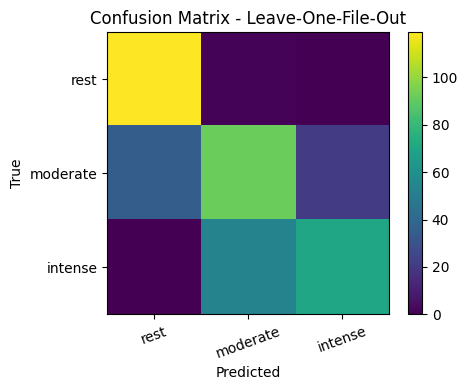

In [12]:
cm = confusion_matrix(all_true, all_preds)
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Leave-One-File-Out")
plt.colorbar()
plt.xticks([0, 1, 2], ["rest", "moderate", "intense"], rotation=20)
plt.yticks([0, 1, 2], ["rest", "moderate", "intense"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "strict_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 7b) SVM Strict Confusion Matrix

[[118   2   0]
 [  0 117  31]
 [  0  52  71]]


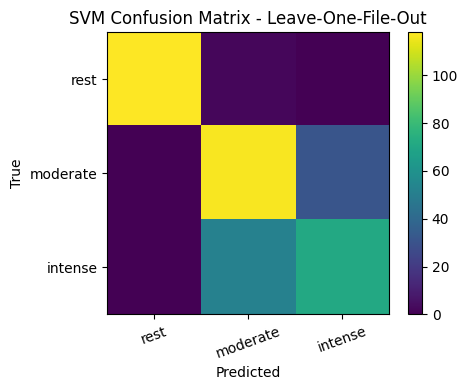

In [13]:
cm_svm_strict = confusion_matrix(all_true_svm, all_preds_svm)
print(cm_svm_strict)

plt.figure(figsize=(5, 4))
plt.imshow(cm_svm_strict, interpolation="nearest")
plt.title("SVM Confusion Matrix - Leave-One-File-Out")
plt.colorbar()
plt.xticks([0, 1, 2], ["rest", "moderate", "intense"], rotation=20)
plt.yticks([0, 1, 2], ["rest", "moderate", "intense"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "chart_strict_svm_confusion_matrix.png", dpi=300)
plt.show()

## 8) Feature importance

jerk_mean         0.087012
jerk_std          0.082702
acc_mag_std       0.075012
emg_state_mean    0.070113
hr_mean           0.066691
hr_max            0.062171
hr_min            0.058875
acc_mag_range     0.041489
ax_std            0.040012
acc_mag_max       0.038720
ay_max            0.036093
acc_mag_min       0.035805
emg_env_mean      0.035367
emg_rms           0.030044
emg_mav           0.028166
emg_raw_mean      0.024930
temp_mean         0.021708
az_std            0.020027
ay_min            0.019874
temp_min          0.015663
dtype: float64


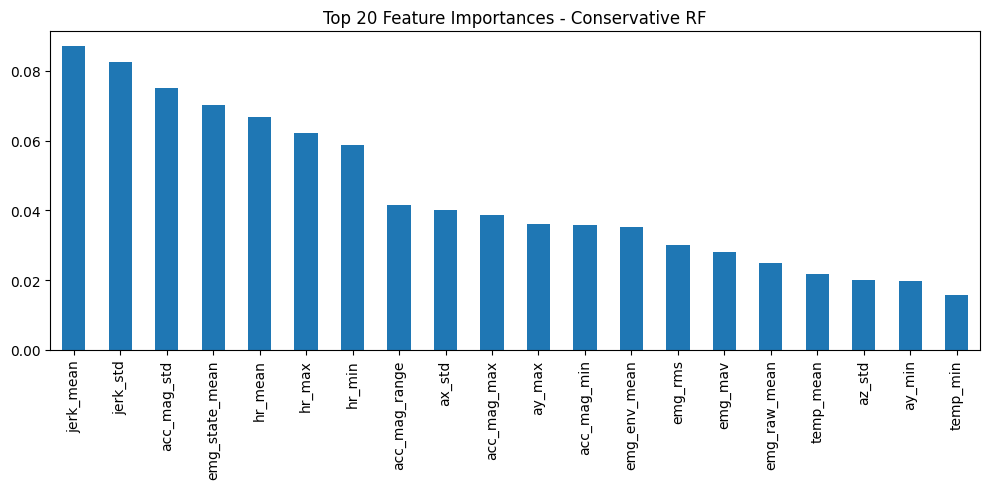

In [14]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=8,
    min_samples_leaf=4,
    random_state=42,
    class_weight="balanced"
)

rf_final.fit(X_all, y_all)

importances = pd.Series(rf_final.feature_importances_, index=X_all.columns).sort_values(ascending=False)

print(importances.head(20))

plt.figure(figsize=(10, 5))
importances.head(20).plot(kind="bar")
plt.title("Top 20 Feature Importances - Conservative RF")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "strict_chart_top_feature_importance.png", dpi=300)
plt.show()

## 9) Save outputs

In [15]:
from pathlib import Path
import joblib

Path("../models/classical").mkdir(parents=True, exist_ok=True)

features_df.to_csv(CSV_DIR / "activity_fusion_features_sensors_strict.csv", index=False)
joblib.dump(rf_final, "../models/classical/activity_classifier_rf_sensors_conservative.pkl")

print("Saved successfully.")

Saved successfully.


## 10) Strict evaluation reuslts

In [16]:
results_df.to_csv(CSV_DIR / "strict_evaluation_results_by_file.csv", index=False)

cm_df = pd.DataFrame(
    cm,
    index=["true_rest", "true_moderate", "true_intense"],
    columns=["pred_rest", "pred_moderate", "pred_intense"]
)
cm_df.to_csv(CSV_DIR / "strict_confusion_matrix.csv")

importances.to_csv(CSV_DIR / "strict_feature_importance.csv", header=["importance"])

print("Strict evaluation outputs saved.")

Strict evaluation outputs saved.


## Summary text file

In [17]:
with open(LOGS_DIR / "strict_metrics_summary.txt", "w", encoding="utf-8") as f:
    f.write("File-by-file results:\n")
    f.write(results_df.to_string(index=False))
    f.write("\n\nMean leave-one-file-out accuracy:\n")
    f.write(str(results_df["accuracy"].mean()))
    f.write("\n\nClassification report:\n")
    f.write(classification_report(all_true, all_preds, target_names=["rest", "moderate", "intense"]))

print("Saved strict metrics summary.")

Saved strict metrics summary.


## Strict by file accuracy

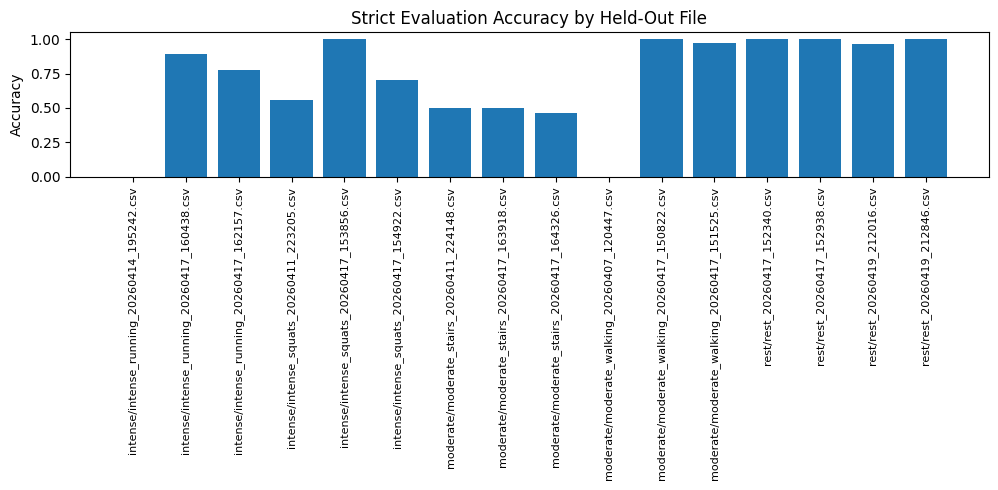

In [18]:
# -----------------------------
# 4. Strict file-by-file accuracy
# -----------------------------
plt.figure(figsize=(10,5))

plt.bar(results_df["test_file"], results_df["accuracy"])
plt.xticks(rotation=90, fontsize=8)
plt.ylim(0,1.05)
plt.ylabel("Accuracy")
plt.title("Strict Evaluation Accuracy by Held-Out File")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "chart_strict_by_file_accuracy.png", dpi=300)
plt.show()

## Chart accuracy comaprison

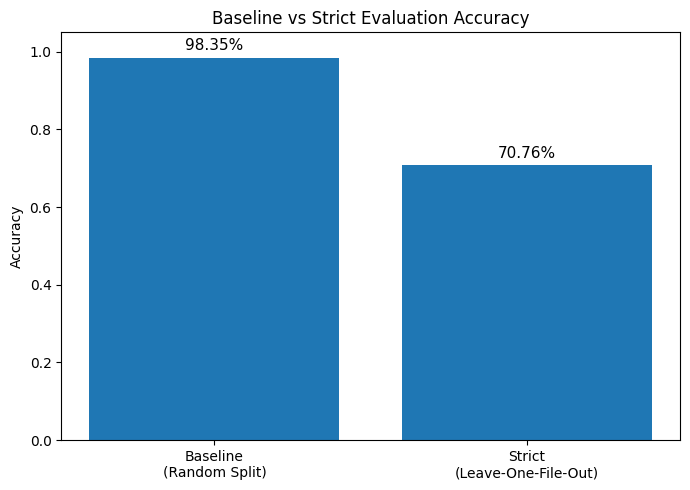

In [19]:


# Values from  experiments

baseline_acc = 0.9835164835164835                  # baseline notebook
strict_acc = results_df["accuracy"].mean()         # strict notebook


plt.figure(figsize=(7,5))
bars = plt.bar(
    ["Baseline\n(Random Split)", "Strict\n(Leave-One-File-Out)"],
    [baseline_acc, strict_acc]
)

plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Baseline vs Strict Evaluation Accuracy")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2%}",
             ha="center", fontsize=11)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "chart_accuracy_comparison.png", dpi=300)
plt.show()

## Strict RF vs SVM Comparison

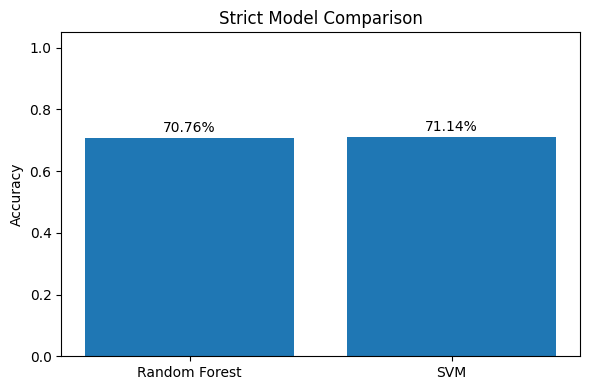

In [20]:
rf_strict_acc = results_df["accuracy"].mean()
svm_strict_acc = results_svm_df["accuracy"].mean()

plt.figure(figsize=(6, 4))
bars = plt.bar(["Random Forest", "SVM"], [rf_strict_acc, svm_strict_acc])
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Strict Model Comparison")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2%}", ha="center")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "chart_strict_rf_vs_svm.png", dpi=300)
plt.show()

## Save SVM Strict Outputs

In [21]:
results_svm_df.to_csv(CSV_DIR / "strict_svm_evaluation_results_by_file.csv", index=False)

pd.DataFrame(
    cm_svm_strict,
    index=["true_rest", "true_moderate", "true_intense"],
    columns=["pred_rest", "pred_moderate", "pred_intense"]
).to_csv(CSV_DIR / "strict_svm_confusion_matrix.csv")

with open(LOGS_DIR / "strict_svm_metrics_summary.txt", "w", encoding="utf-8") as f:
    f.write("SVM Strict Evaluation Results (Leave-One-File-Out)\n")
    f.write("=" * 60)

    f.write("\n\nFile-by-file results:\n")
    f.write(results_svm_df.to_string(index=False))

    f.write("\n\nMean leave-one-file-out accuracy:\n")
    f.write(str(results_svm_df["accuracy"].mean()))

    f.write("\n\nClassification report:\n")
    f.write(classification_report(
        all_true_svm,
        all_preds_svm,
        target_names=["rest", "moderate", "intense"]
    ))

print("Saved strict SVM outputs.")

Saved strict SVM outputs.


## Table summary for charting

In [22]:
# RF strict
rf_report = classification_report(all_true, all_preds, output_dict=True)
rf_acc = results_df["accuracy"].mean()

# SVM strict
svm_report = classification_report(all_true_svm, all_preds_svm, output_dict=True)
svm_acc = results_svm_df["accuracy"].mean()

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Random Forest": [
        rf_acc,
        rf_report["macro avg"]["precision"],
        rf_report["macro avg"]["recall"],
        rf_report["macro avg"]["f1-score"]
    ],
    "SVM": [
        svm_acc,
        svm_report["macro avg"]["precision"],
        svm_report["macro avg"]["recall"],
        svm_report["macro avg"]["f1-score"]
    ]
})

metrics_df

,Metric,Random Forest,SVM
0,Accuracy,0.707618,0.711419
1,Precision,0.724032,0.793430
2,Recall,0.727465,0.783703
3,F1,0.716223,0.785417


## Plot strict metrics comparison chart

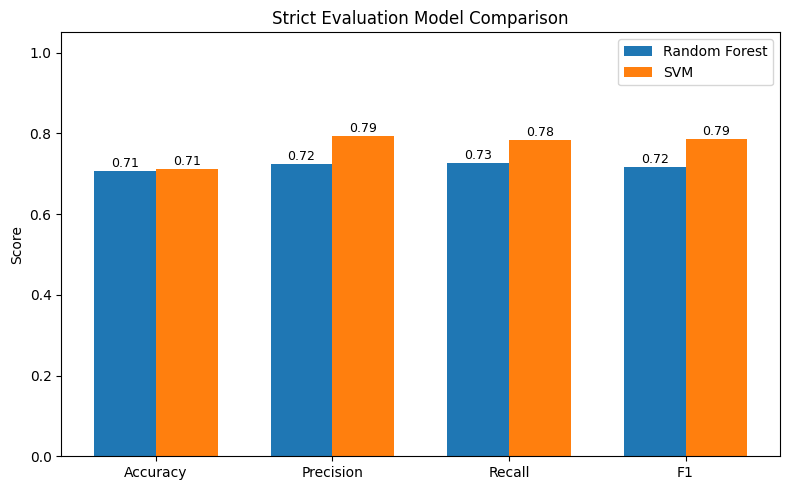

: 

In [ ]:
# Plot strict chart
x = np.arange(len(metrics_df["Metric"]))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, metrics_df["Random Forest"], width, label="Random Forest")
plt.bar(x + width/2, metrics_df["SVM"], width, label="SVM")

plt.xticks(x, metrics_df["Metric"])
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Strict Evaluation Model Comparison")
plt.legend()

for i, v in enumerate(metrics_df["Random Forest"]):
    plt.text(i - width/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

for i, v in enumerate(metrics_df["SVM"]):
    plt.text(i + width/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "chart_strict_metrics_rf_vs_svm.png", dpi=300)
plt.show()